# FAPE, Cross-Domain Fairness Comparison
## Stage 2: ThresholdOptimizer Results Across All 7 Domains

**Purpose:** Aggregate and compare fairness intervention results across all 7 FAPE datasets.

**Datasets:** COMPAS, Folktables, Law School, Lending Club, Agricultural, FairGround, Student

**Key findings:**
- Law School: largest racial gap (DIR=0.643); strongest improvement (EO +94.1% reduction)
- FairGround: strongest DP improvement (92.4%) but highest accuracy cost (0.159)
- Agricultural + Lending Club: near-fair baseline, ThresholdOptimizer counterproductive
- COMPAS: GB DP constraint most effective (DPD 0.857→0.571)
- Student: EO constraint eliminates sex gap (EOD 0.314→0.055)
- **Core finding:** ThresholdOptimizer effective when baseline DPD > 0.2; counterproductive when < 0.05

In [1]:
import sys, os, warnings, logging
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore'); logging.disable(logging.CRITICAL)
from IPython.display import Image
from cross_domain_comparison import run_cross_domain_comparison
print('Imports complete')

Imports complete


In [2]:
import os
os.chdir('..')  # move to repo root so data paths resolve
results = run_cross_domain_comparison()
os.chdir('notebooks')
print('Cross-domain comparison complete')

FAPE, Cross-Domain Fairness Comparison

--- Domain Summary ---
  COMPAS          DP improve: +33.3% | EO improve: +36.1% | ACC cost (DP): 0.008
  Folktables      DP improve: -6.2% | EO improve: +0.6% | ACC cost (DP): 0.019
  Law School      DP improve: +88.9% | EO improve: +94.1% | ACC cost (DP): 0.003
  Lending Club    DP improve: -0.1% | EO improve: -7.0% | ACC cost (DP): 0.001
  Agricultural    DP improve: -288.9% | EO improve: -165.8% | ACC cost (DP): 0.026
  FairGround      DP improve: +92.4% | EO improve: +92.7% | ACC cost (DP): 0.159
  Student         DP improve: +19.8% | EO improve: +82.5% | ACC cost (DP): 0.063

--- Key Cross-Domain Findings ---
  Law School: largest racial gap (DIR=0.643); strongest improvement (EO +94.1%)
  FairGround: strongest DP improvement (92.4%) but highest ACC cost (0.159)
  Agricultural + Lending Club: near-fair baseline, ThresholdOptimizer counterproductive
  COMPAS: GB DP constraint most effective (DPD 0.857→0.571)
  Student: EO constraint eliminat

  Fig 3 saved - cross_domain_acc_fairness_scatter.png
  Fig 4 saved - cross_domain_dir_comparison.png
  Fig 5 saved - cross_domain_metrics_heatmap.png


  Fig 6 saved - cross_domain_improvement_ranking.png

--- Cross-Domain Comparison complete ---
  6 figures saved to figures/stage2/
  ThresholdOptimizer effective when baseline DPD > 0.2
  Counterproductive when baseline near-fair (Agricultural DPD=0.009, Lending Club DPD=0.024)
  Law School strongest violation + strongest improvement
  FairGround highest accuracy cost for improvement
Cross-domain comparison complete


## 1. Demographic Parity Disparity, Before vs After

DPD before and after ThresholdOptimizer across all 7 domains. Law School and COMPAS show largest baseline violations. Agricultural and Lending Club near-fair baseline, ThresholdOptimizer counterproductive.

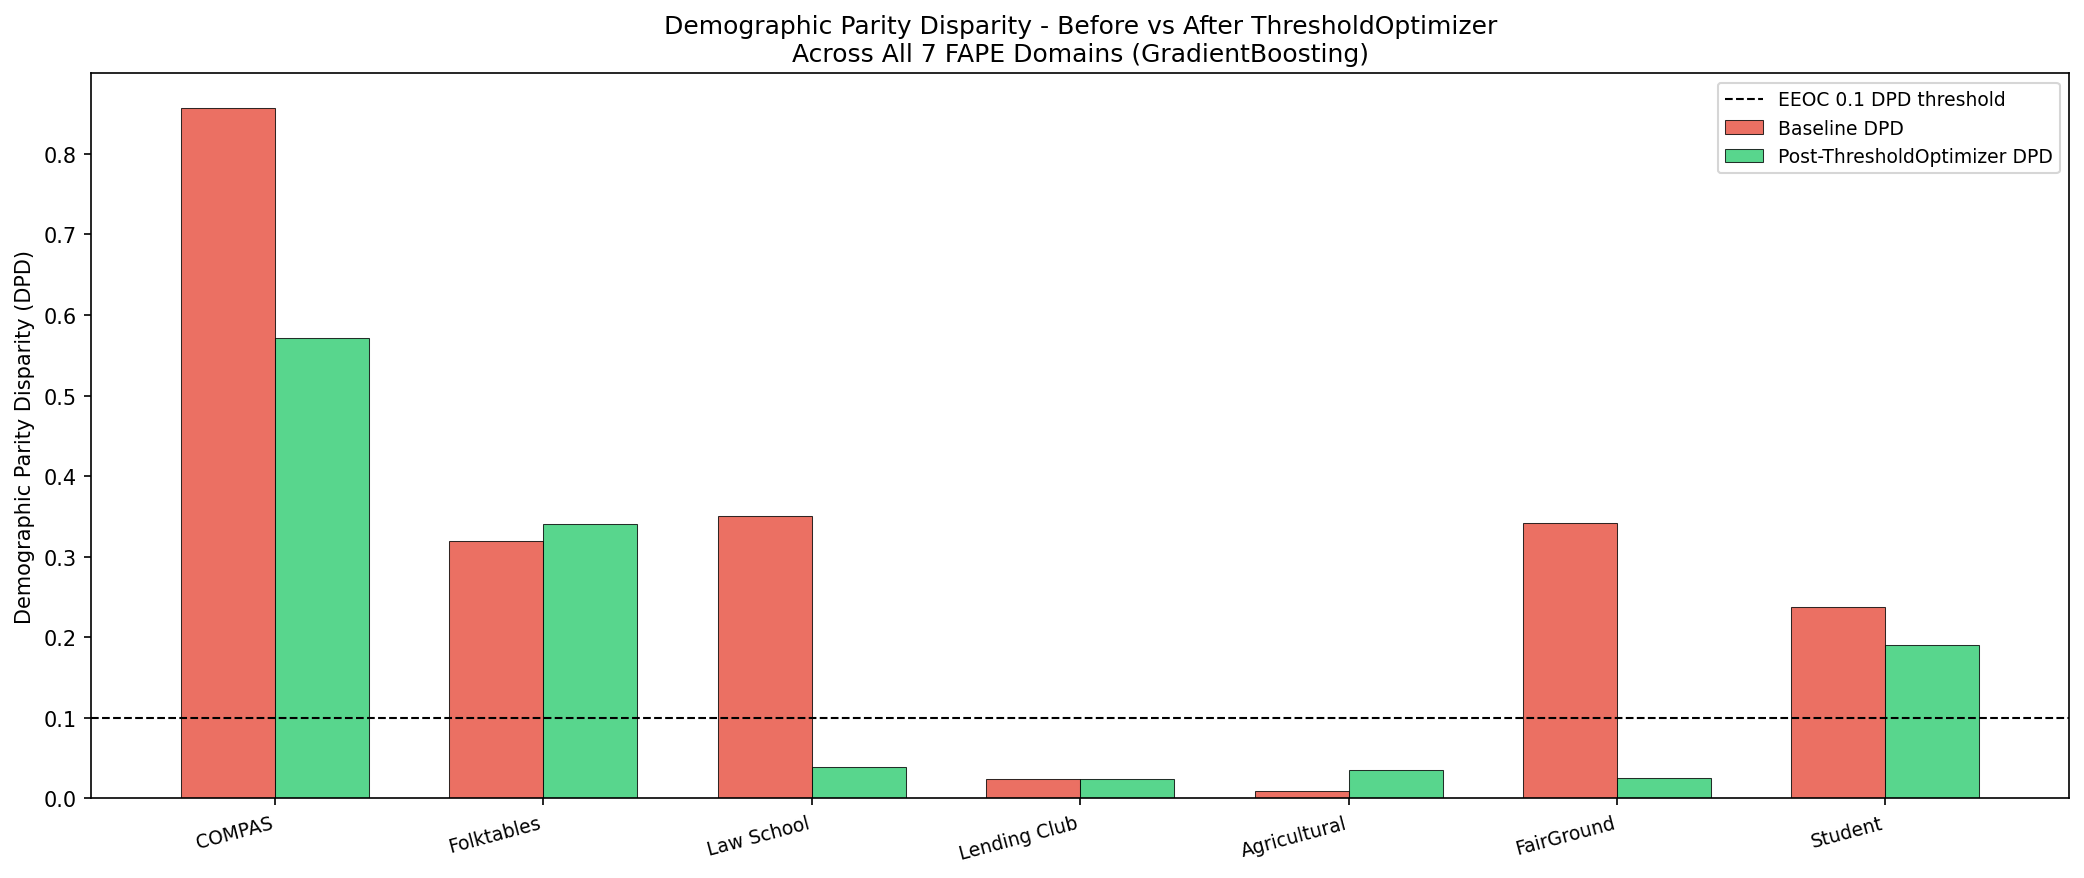

In [3]:
Image('../figures/stage2/cross_domain_dpd_comparison.png')

## 2. Equalized Odds Disparity, Before vs After

EOD before and after ThresholdOptimizer. Law School (EOD 0.528→0.031) and FairGround (EOD 0.518→0.038) show strongest improvement. COMPAS baseline EOD=1.000, perfect disparity, reduced to 0.639.

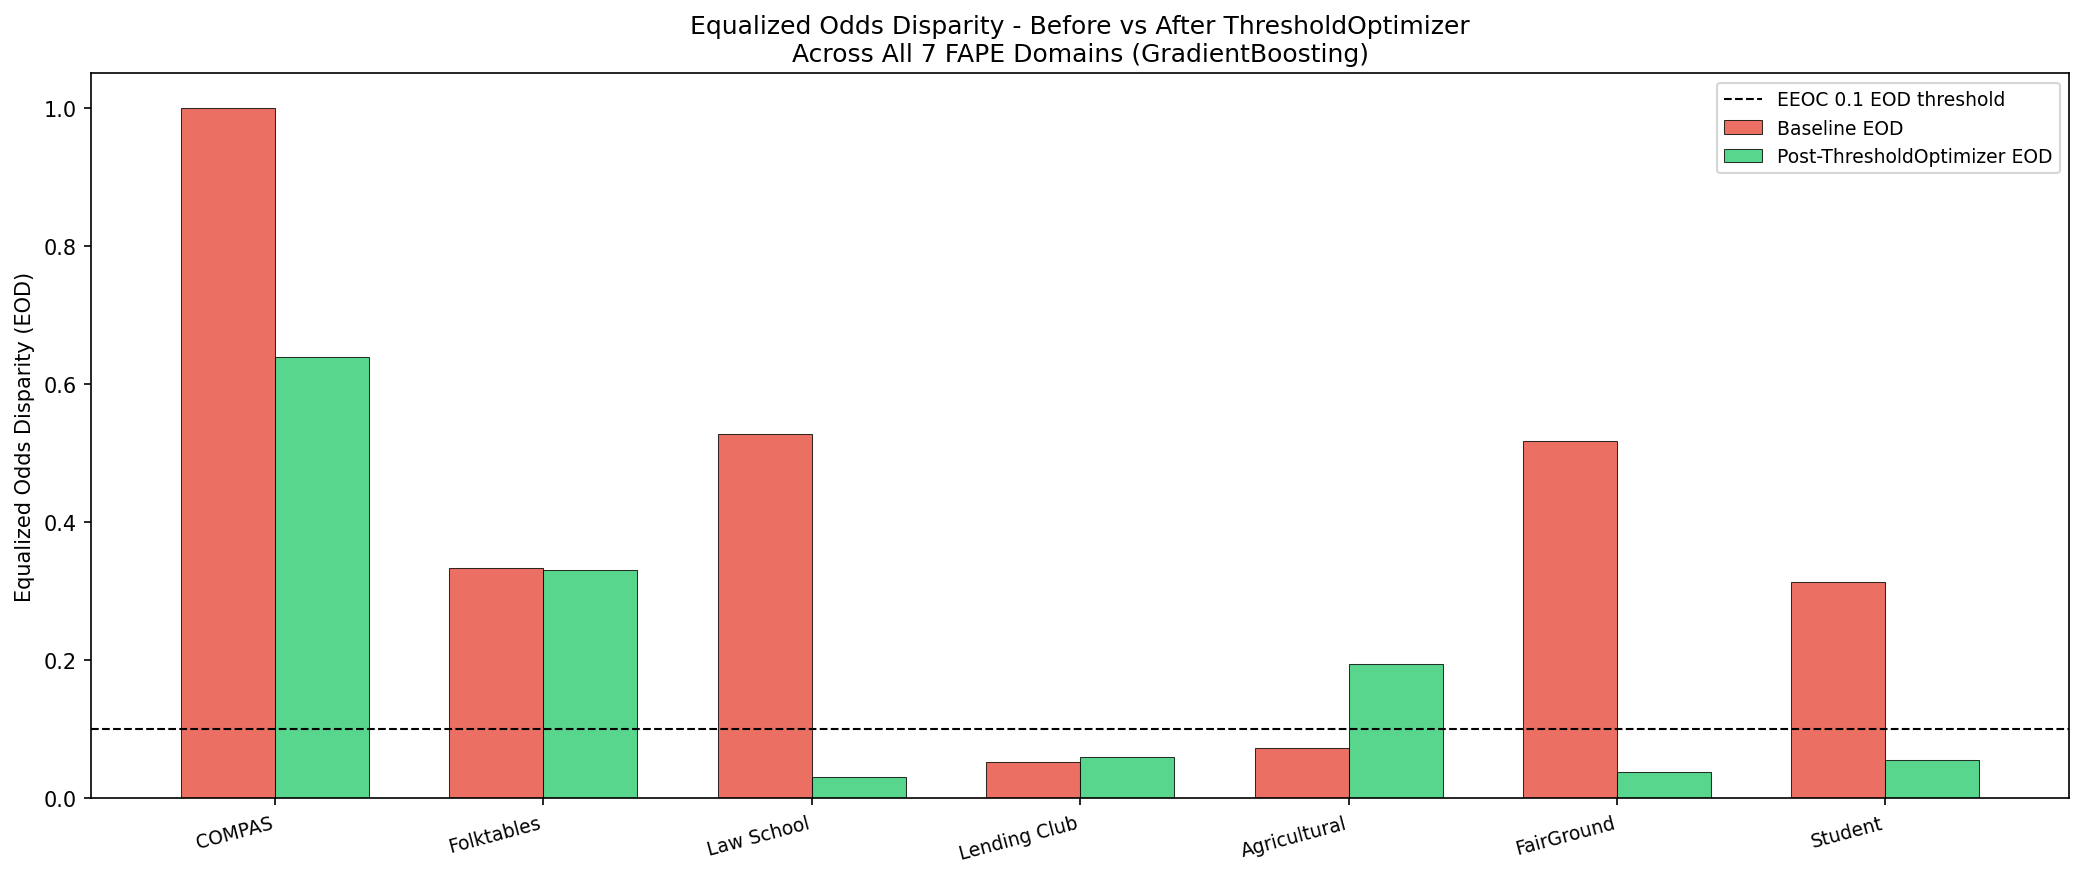

In [4]:
Image('../figures/stage2/cross_domain_eod_comparison.png')

## 3. Accuracy-Fairness Tradeoff Scatter

Accuracy cost vs fairness improvement across all 7 domains. Upper-left quadrant: high improvement, low cost (Law School, Student EO). Lower-right: high cost, degradation (Agricultural, Lending Club).

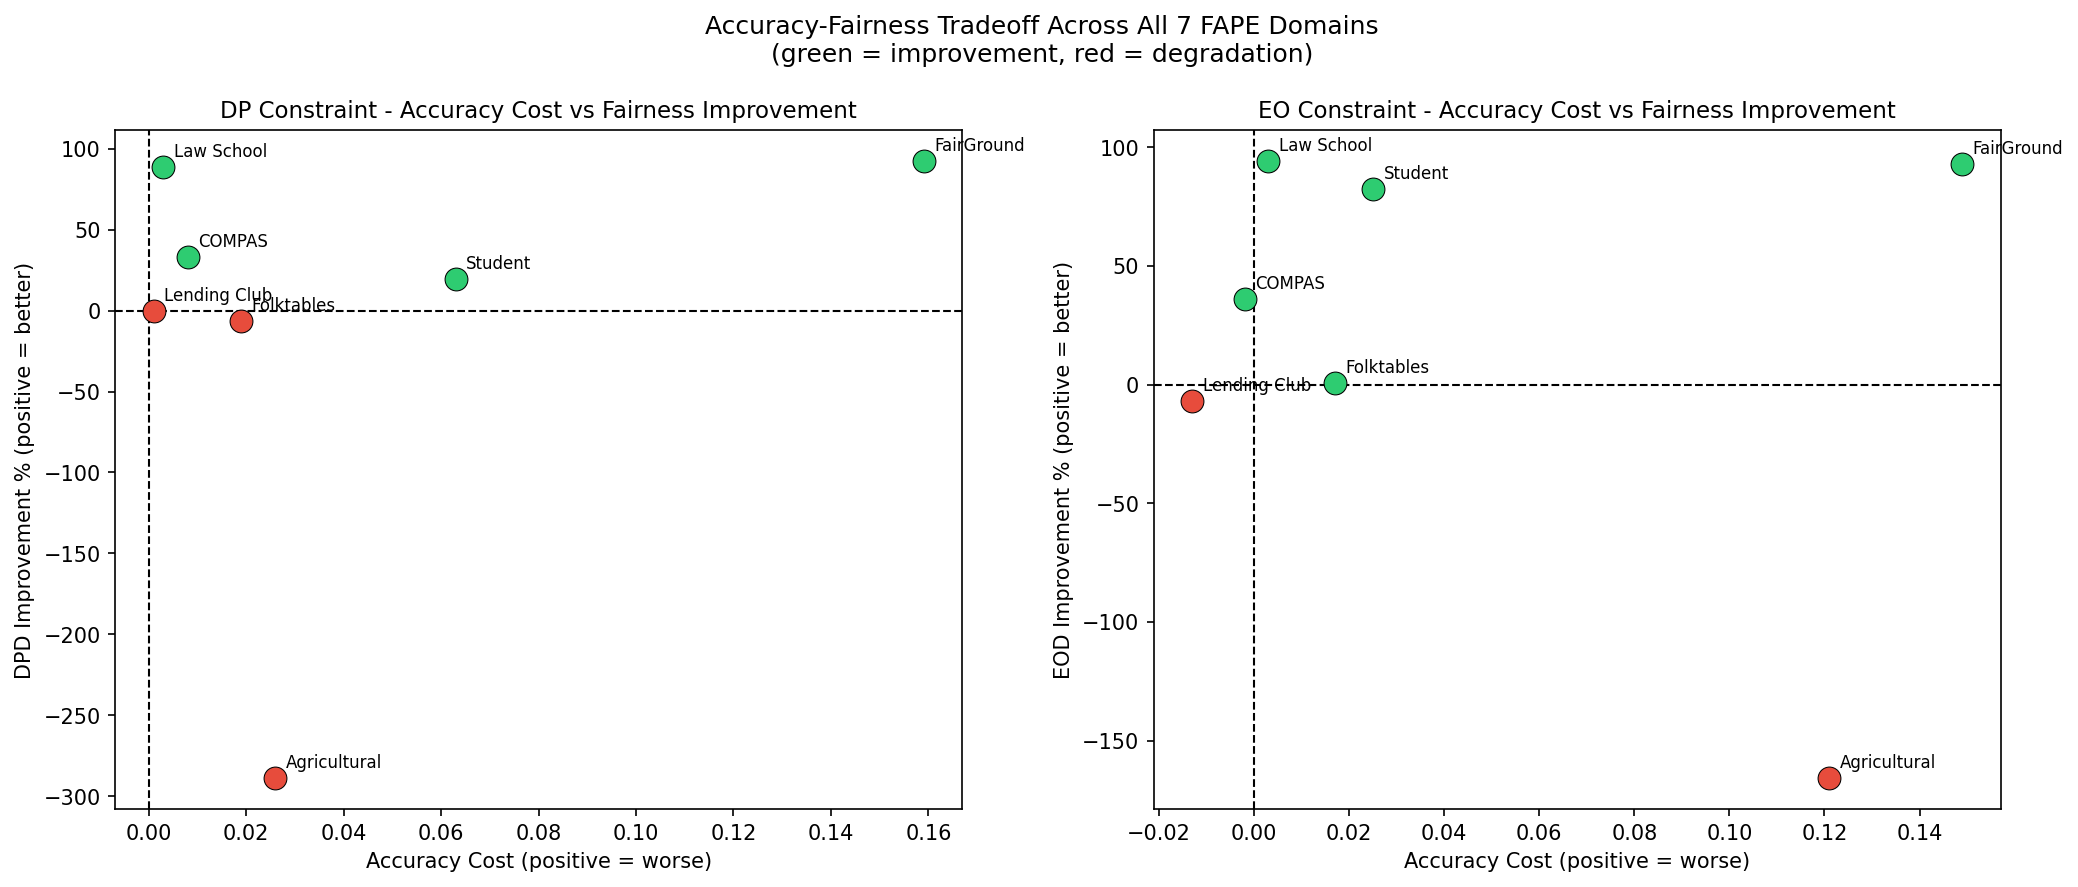

In [5]:
Image('../figures/stage2/cross_domain_acc_fairness_scatter.png')

## 4. Disparate Impact Ratio, Before vs After

DIR before and after ThresholdOptimizer for Law School, Lending Club, and Agricultural. Law School: DIR 0.643→0.945, passes EEOC 80% rule. Lending Club: DIR 2.778→0.952, corrects model amplification. Agricultural: DIR 0.653→1.095, overcorrects past parity.

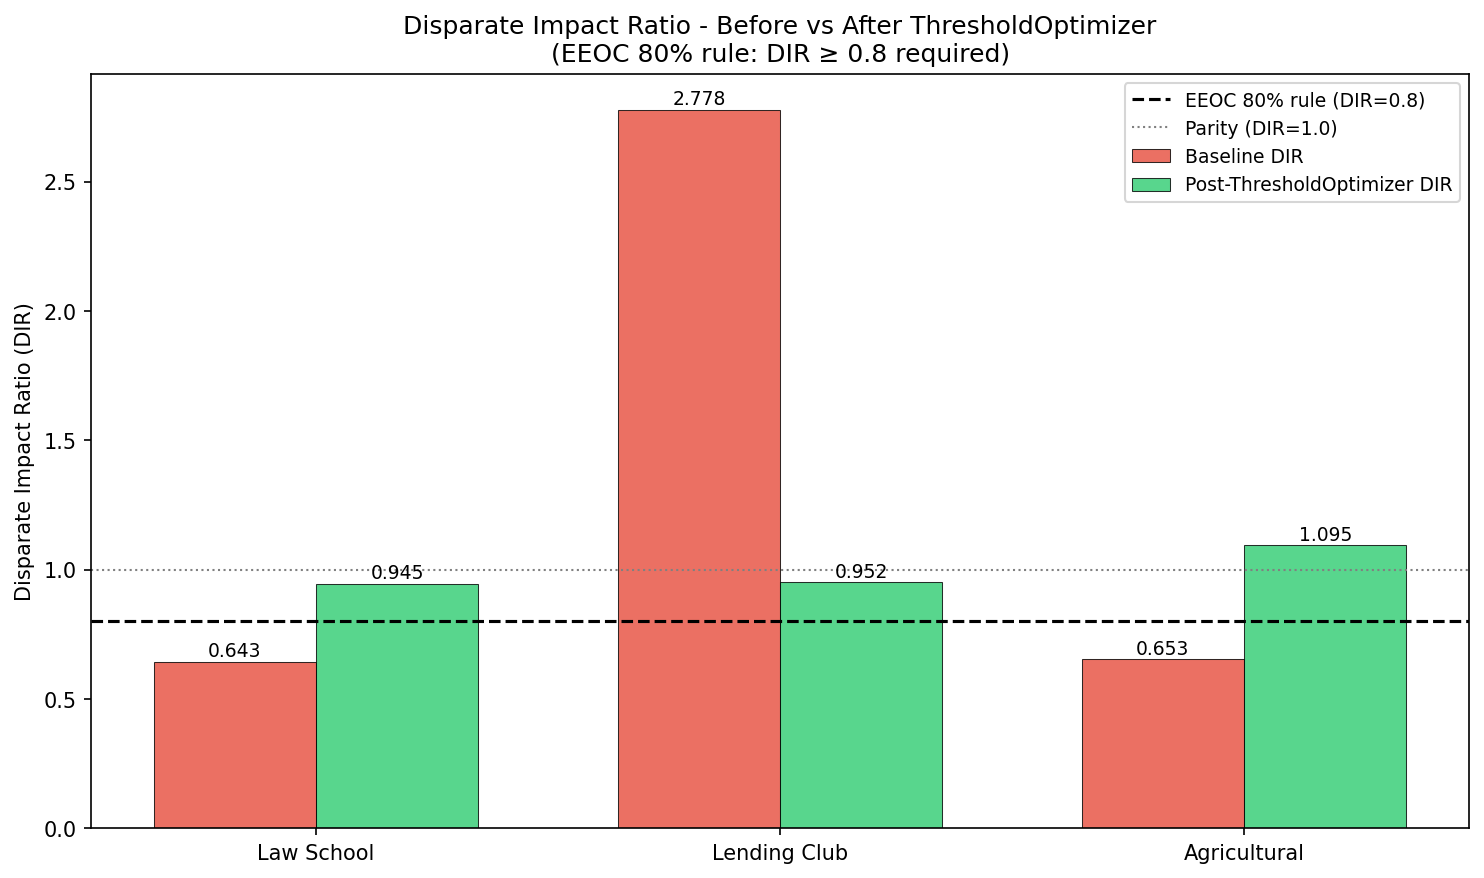

In [6]:
Image('../figures/stage2/cross_domain_dir_comparison.png')

## 5. Cross-Domain Metrics Summary Heatmap

Full metrics matrix across all 7 domains, baseline DPD, post-DP DPD, baseline EOD, post-EO EOD, accuracy cost. Red = high disparity/cost, green = low disparity/cost.

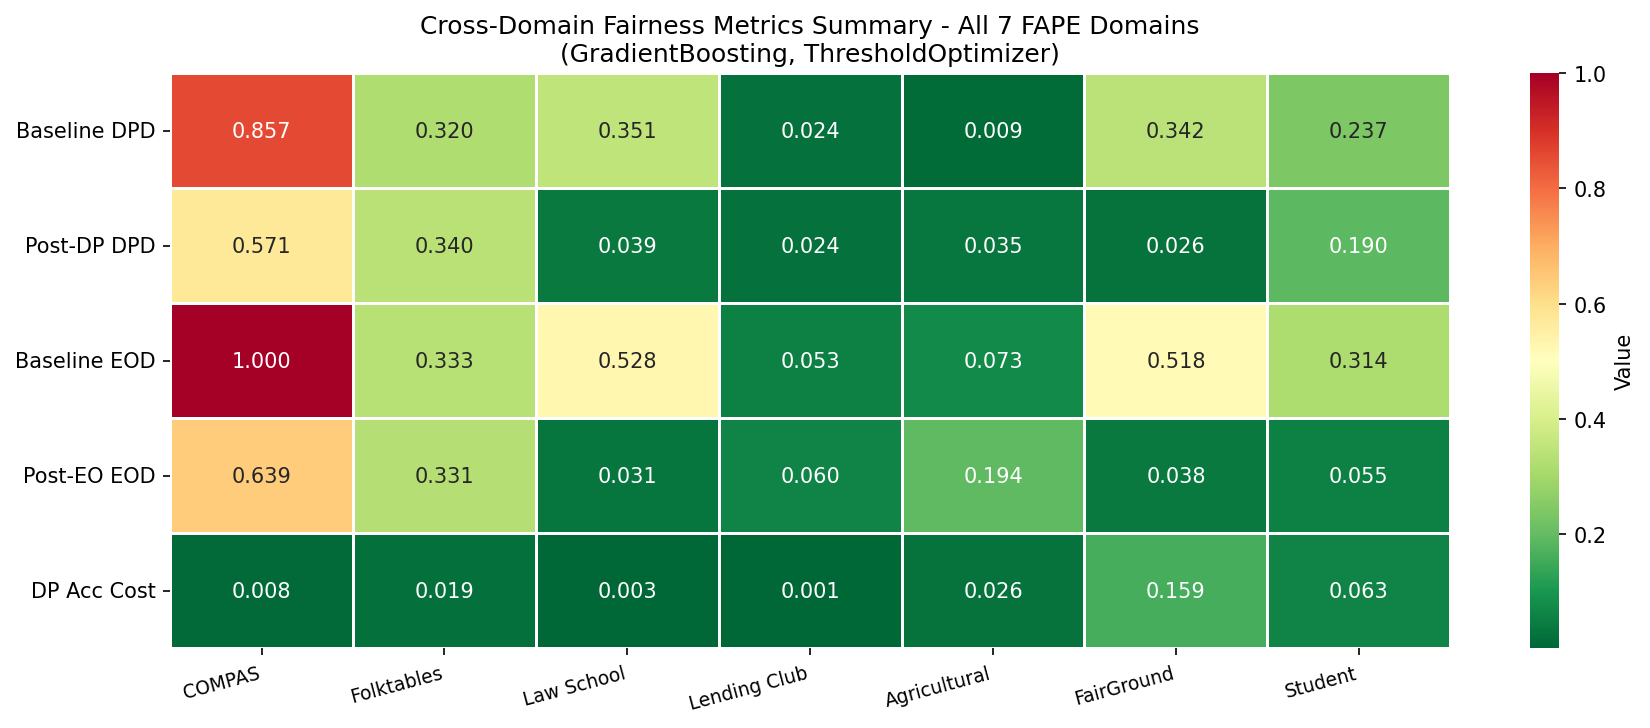

In [7]:
Image('../figures/stage2/cross_domain_metrics_heatmap.png')

## 6. ThresholdOptimizer Effectiveness Ranking

All 7 domains ranked by DP and EO improvement percentage. Law School and FairGround top performers. Agricultural (-288.9%) and Lending Club most counterproductive, near-fair baselines.

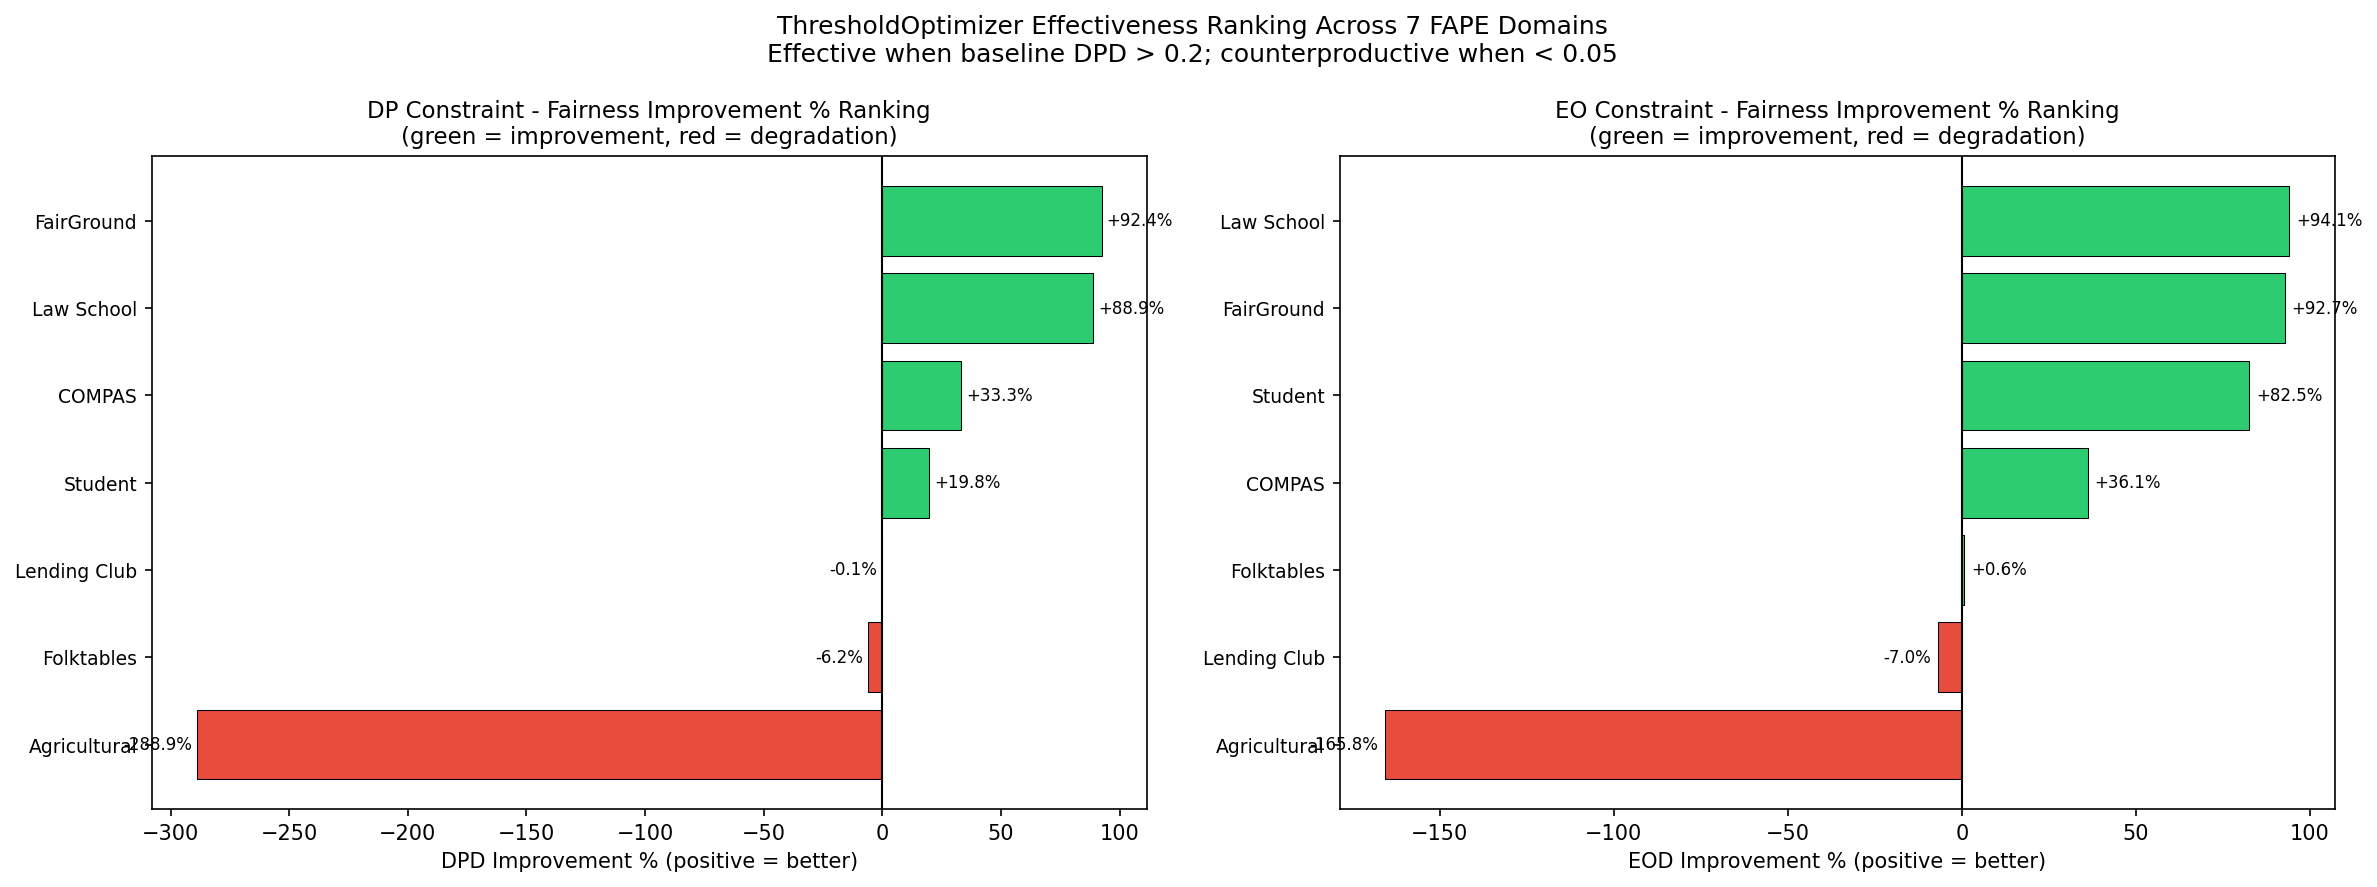

In [8]:
Image('../figures/stage2/cross_domain_improvement_ranking.png')

## 7. Key Findings

**ThresholdOptimizer effectiveness is baseline-dependent:**
- Effective (DPD > 0.2): Law School (+88.9%), FairGround (+92.4%), Student EO (+82.5%)
- Marginal (DPD 0.2-0.3): COMPAS (+33.3%), Folktables (minimal)
- Counterproductive (DPD < 0.05): Agricultural (-288.9%), Lending Club (-7.0%)

**Regulatory compliance post-intervention:**
- Law School: DIR 0.643→0.945, passes EEOC 80% rule 
- Lending Club: DIR 2.778→0.952, corrects model amplification 
- Agricultural: DIR 0.653→1.095, overcorrects past parity 

**Accuracy-fairness tradeoff:**
- Best tradeoff: Law School (EO +94.1% at 0.003 ACC cost)
- Worst tradeoff: FairGround (DP +92.4% at 0.159 ACC cost)
- Near-zero cost: COMPAS GB (EO +36.1% at -0.002 ACC cost, accuracy improves)

**FAPE contribution:**
Cross-domain audit reveals ThresholdOptimizer is not universally applicable. Near-fair baselines require different intervention strategies. This finding motivates domain-specific fairness auditing in production ML pipelines.